Goal: Home and Work location distribution in relation to the Overture POIs

In [31]:
import duckdb
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

In [12]:
individuals_df = pd.read_csv("data/individuals_dataset.csv")
unique_geoids = individuals_df['CODGEO'].unique()
individuals_df

,ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,...,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
0,10_2978,78092,Bougival,Woman,41,NaN,4,In a couple with child(ren),2,1,...,1,2,0,False,False,False,False,False,1856.206160,True
1,10_2980,75120,Paris,Man,30,5-year-and-above higher education degree: Mast...,2,Living alone,1,0,...,0,0,0,True,False,False,False,False,1375.000372,True
2,10_2981,91326,Juvisy-sur-Orge,Man,38,5-year-and-above higher education degree: Mast...,2,In a couple without children,2,0,...,0,1,0,True,False,False,False,False,1231.812990,True
3,10_2982,91573,Saint-Pierre-du-Perray,Man,43,"3–4-year higher education degree: Licence, Pro...",2,Single parent (divorced / separated / widowed),1,1,...,0,2,0,True,False,False,False,False,426.311616,True
4,10_2984,78073,Bois-d'Arcy,Woman,39,5-year-and-above higher education degree: Mast...,2,Living alone,1,0,...,0,1,0,True,False,False,True,False,843.194726,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3332,7_2972,95127,Cergy,Woman,59,5-year-and-above higher education degree: Mast...,2,In a couple without children,1,0,...,0,0,0,False,False,False,False,False,608.890788,True
3333,7_2973,91461,Ollainville,Woman,42,NaN,2,In a couple with child(ren),5,1,...,0,2,0,False,False,False,False,False,786.094977,True
3334,7_2974,91534,Saclay,Man,52,"3–4-year higher education degree: Licence, Pro...",2,In a couple with child(ren),3,0,...,0,2,0,False,False,False,False,False,1819.688178,True
3335,7_2975,91573,Saint-Pierre-du-Perray,Woman,58,NaN,4,In a couple with child(ren),4,0,...,0,0,0,True,False,False,False,False,962.525230,True


<Axes: >

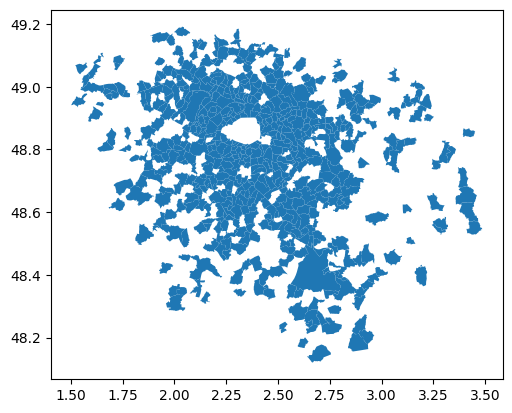

In [23]:
communes = gpd.read_file("data/communes_france.geojson")
communes = communes[communes["code"].astype(str).isin(unique_geoids.astype(str))]
communes.plot()

In [25]:
# 1. Ensure the grouping key is treated as a string
individuals_df['CODGEO'] = individuals_df['CODGEO'].astype(str)

# 2. Also ensure 'communes' uses strings for its 'code' column, just in case
communes['code'] = communes['code'].astype(str)

# 3. Now run your group-by and merge seamlessly
counts_df = individuals_df.groupby('CODGEO').size().reset_index(name='individual_count')
communes_with_counts = communes.merge(counts_df, left_on='code', right_on='CODGEO', how='left')

# 4. Fill missing values with 0
communes_with_counts['individual_count'] = communes_with_counts['individual_count'].fillna(0)

In [29]:
communes_with_counts

,code,nom,geometry,CODGEO,individual_count
0,77322,Moussy-le-Neuf,"POLYGON ((2.61034 49.09494, 2.6169 49.09389, 2...",77322,2
1,94018,Charenton-le-Pont,"POLYGON ((2.41959 48.81691, 2.4159 48.81633, 2...",94018,11
2,94019,Chennevières-sur-Marne,"POLYGON ((2.52228 48.80407, 2.52704 48.80514, ...",94019,1
3,94022,Choisy-le-Roi,"POLYGON ((2.44255 48.76196, 2.44142 48.76119, ...",94022,16
4,94041,Ivry-sur-Seine,"POLYGON ((2.36722 48.80803, 2.36549 48.80922, ...",94041,10
...,...,...,...,...,...
573,77271,Maisoncelles-en-Gâtinais,"POLYGON ((2.62243 48.167, 2.61752 48.16759, 2....",77271,1
574,77348,Ormesson,"POLYGON ((2.63352 48.24633, 2.63366 48.24509, ...",77348,1
575,77370,Poligny,"POLYGON ((2.72767 48.257, 2.731 48.26452, 2.74...",77370,1
576,77431,Saint-Pierre-lès-Nemours,"POLYGON ((2.63352 48.24633, 2.63444 48.24861, ...",77431,1


In [28]:
communes_with_counts["individual_count"]

0       2
1      11
2       1
3      16
4      10
       ..
573     1
574     1
575     1
576     1
577     1
Name: individual_count, Length: 578, dtype: int64

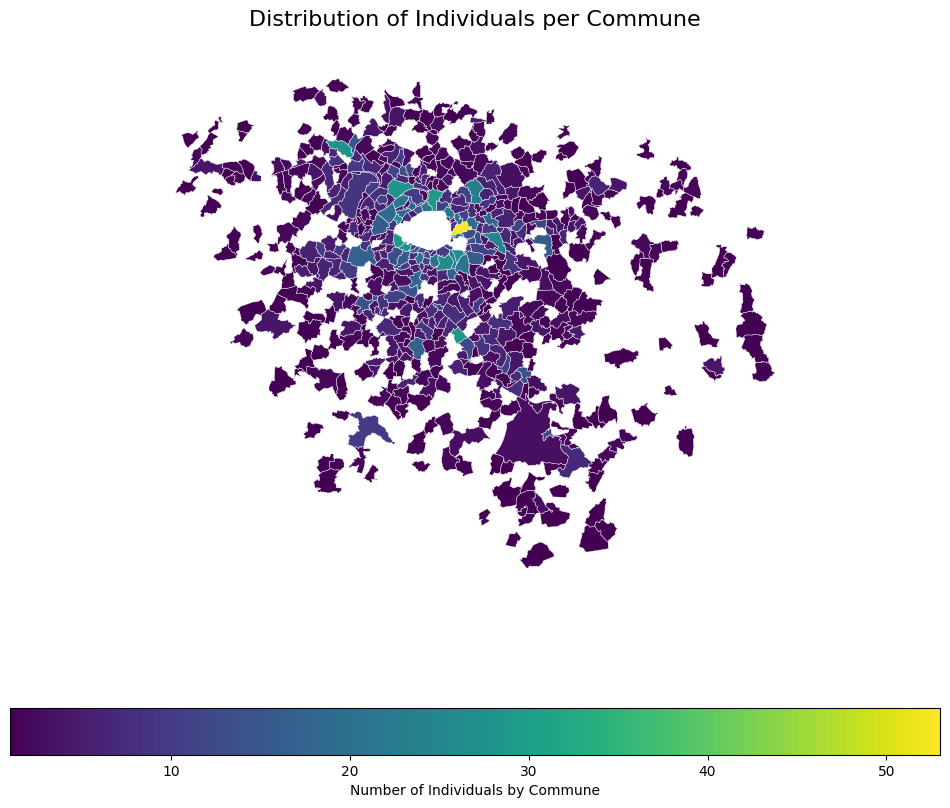

In [32]:
# 2. Plot the map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

communes_with_counts.plot(
    column='individual_count',
    cmap='viridis',          # 'viridis', 'plasma', 'YlOrRd', or 'Blues' work great
    legend=True,
    legend_kwds={'label': "Number of Individuals by Commune", 'orientation': "horizontal"},
    edgecolor='white',       # Adds clear borders between the communes
    linewidth=0.3,
    ax=ax
)

# 3. Clean up the axes for a nice map look
ax.set_title('Distribution of Individuals per Commune', fontsize=16, pad=20)
ax.axis('off')

plt.show()

## Cross-Dataset HOME-WORK Distance Comparison

This section compares observed HOME-WORK distances with the distances implied by simulated profile anchors for YJMob, Shanghai, and GParis. It does not run trajectory simulation; it only runs the current POI+building anchor/profile assignment logic.

In [ ]:

from __future__ import annotations

from pathlib import Path
import os

import duckdb
import h3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from citybehavex.config import load_config
from citybehavex.profiles import generate_profiles
from citybehavex.simulation.runner import (
    _append_work_scores,
    _derive_home_anchor_candidates_from_tessellation,
    _load_or_build_tessellation_df,
)

sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "configs").exists() and (candidate / "data").exists():
            return candidate
    return Path("../..").resolve()


PROJECT_ROOT = find_project_root()


def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))


def h3_latlng_frame(cells: pd.Series) -> pd.DataFrame:
    latlng = [h3.cell_to_latlng(str(cell)) for cell in cells]
    return pd.DataFrame(latlng, columns=["lat", "lon"])


def summarize_home_work_distances(city: str, source: str, distances_km: pd.Series | np.ndarray) -> dict:
    distances = pd.Series(distances_km, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    quantiles = distances.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95]) if len(distances) else pd.Series(dtype=float)
    return {
        "city": city,
        "source": source,
        "n_users": int(len(distances)),
        "mean_km": distances.mean(),
        "std_km": distances.std(),
        "median_km": quantiles.get(0.50, np.nan),
        "p10_km": quantiles.get(0.10, np.nan),
        "p25_km": quantiles.get(0.25, np.nan),
        "p75_km": quantiles.get(0.75, np.nan),
        "p90_km": quantiles.get(0.90, np.nan),
        "p95_km": quantiles.get(0.95, np.nan),
        "max_km": distances.max() if len(distances) else np.nan,
        "share_le_2km": distances.le(2).mean() if len(distances) else np.nan,
        "share_le_5km": distances.le(5).mean() if len(distances) else np.nan,
        "share_le_10km": distances.le(10).mean() if len(distances) else np.nan,
        "share_le_20km": distances.le(20).mean() if len(distances) else np.nan,
    }

def observed_yjmob_home_work() -> pd.DataFrame:
    con = duckdb.connect()
    con.sql("INSTALL h3 FROM community; LOAD h3;")
    path = PROJECT_ROOT / "data/yjmob/yjmob_wgs84_simple.parquet"
    anchors = con.sql(f"""
        WITH obs AS (
            SELECT
                uid,
                h3_latlng_to_cell_string(lat, lon, 8) AS h3_cell,
                CAST(FLOOR(t / 2) AS INTEGER) AS obs_hour,
                (d % 7 BETWEEN 1 AND 5) AS is_weekday
            FROM read_parquet('{path}')
            WHERE lat IS NOT NULL AND lon IS NOT NULL
        ), home_counts AS (
            SELECT uid, h3_cell, COUNT(*) AS records
            FROM obs
            WHERE obs_hour BETWEEN 2 AND 5
            GROUP BY uid, h3_cell
        ), homes AS (
            SELECT uid, h3_cell AS home_cell
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY uid ORDER BY records DESC, h3_cell) AS rn
                FROM home_counts
            )
            WHERE rn = 1
        ), work_counts AS (
            SELECT o.uid, o.h3_cell, COUNT(*) AS records
            FROM obs o
            LEFT JOIN homes h USING(uid)
            WHERE o.is_weekday
              AND (o.obs_hour = 10 OR o.obs_hour BETWEEN 14 AND 16)
              AND o.h3_cell <> h.home_cell
            GROUP BY o.uid, o.h3_cell
        ), works AS (
            SELECT uid, h3_cell AS work_cell
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY uid ORDER BY records DESC, h3_cell) AS rn
                FROM work_counts
            )
            WHERE rn = 1
        )
        SELECT h.uid, h.home_cell, w.work_cell
        FROM homes h
        JOIN works w USING(uid)
    """).df()
    home_xy = h3_latlng_frame(anchors["home_cell"])
    work_xy = h3_latlng_frame(anchors["work_cell"])
    anchors["home_work_km"] = haversine_km(home_xy["lat"], home_xy["lon"], work_xy["lat"], work_xy["lon"])
    return anchors


def observed_shanghai_home_work() -> pd.DataFrame:
    con = duckdb.connect()
    con.sql("INSTALL h3 FROM community; LOAD h3;")
    path = PROJECT_ROOT / "data/shanghai/shanghai_data_raw.parquet"
    anchors = con.sql(f"""
        WITH obs AS (
            SELECT
                user_id,
                h3_latlng_to_cell_string(lat, long, 8) AS h3_cell,
                CAST(EXTRACT('hour' FROM CAST(timestamp AS TIMESTAMP)) AS INTEGER) AS obs_hour,
                (EXTRACT('dow' FROM CAST(timestamp AS TIMESTAMP)) BETWEEN 1 AND 5) AS is_weekday
            FROM read_parquet('{path}')
            WHERE lat IS NOT NULL AND long IS NOT NULL
        ), home_counts AS (
            SELECT user_id, h3_cell, COUNT(*) AS records
            FROM obs
            WHERE obs_hour BETWEEN 2 AND 5
            GROUP BY user_id, h3_cell
        ), homes AS (
            SELECT user_id, h3_cell AS home_cell
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY records DESC, h3_cell) AS rn
                FROM home_counts
            )
            WHERE rn = 1
        ), work_counts AS (
            SELECT o.user_id, o.h3_cell, COUNT(*) AS records
            FROM obs o
            LEFT JOIN homes h USING(user_id)
            WHERE o.is_weekday
              AND (o.obs_hour = 10 OR o.obs_hour BETWEEN 14 AND 16)
              AND o.h3_cell <> h.home_cell
            GROUP BY o.user_id, o.h3_cell
        ), works AS (
            SELECT user_id, h3_cell AS work_cell
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY records DESC, h3_cell) AS rn
                FROM work_counts
            )
            WHERE rn = 1
        )
        SELECT h.user_id, h.home_cell, w.work_cell
        FROM homes h
        JOIN works w USING(user_id)
    """).df()
    home_xy = h3_latlng_frame(anchors["home_cell"])
    work_xy = h3_latlng_frame(anchors["work_cell"])
    anchors["home_work_km"] = haversine_km(home_xy["lat"], home_xy["lon"], work_xy["lat"], work_xy["lon"])
    return anchors


def observed_gparis_home_work() -> pd.DataFrame:
    visits = pd.read_parquet(PROJECT_ROOT / "data/gparis/gparis_visitation_df.parquet")

    def most_frequent_purpose_location(purpose: str) -> pd.DataFrame:
        grouped = (
            visits[visits["purpose"].eq(purpose)]
            .groupby(["user_id", "area"], as_index=False)
            .agg(records=("area", "size"), lat=("lat", "mean"), lon=("lon", "mean"))
            .sort_values(["user_id", "records", "area"], ascending=[True, False, True])
        )
        return grouped.groupby("user_id", as_index=False).head(1)

    homes = most_frequent_purpose_location("HOME").rename(
        columns={"area": "home_cell", "lat": "home_lat", "lon": "home_lon", "records": "home_records"}
    )
    works = most_frequent_purpose_location("WORK").rename(
        columns={"area": "work_cell", "lat": "work_lat", "lon": "work_lon", "records": "work_records"}
    )
    anchors = homes.merge(works, on="user_id", how="inner")
    anchors["home_work_km"] = haversine_km(
        anchors["home_lat"], anchors["home_lon"], anchors["work_lat"], anchors["work_lon"]
    )
    return anchors


def simulated_anchor_home_work_distances(config_rel_path: str, building_cache_rel_path: str) -> pd.DataFrame:
    building_cache = PROJECT_ROOT / building_cache_rel_path
    if not building_cache.exists():
        print(
            f"Skipping simulated-anchor distances for {config_rel_path}: missing {building_cache}. "
            "Build/fetch this Overture building feature cache before running this comparison."
        )
        return pd.DataFrame(columns=["uid", "home_tile", "work_tile", "home_work_km"])

    cwd = Path.cwd()
    os.chdir(PROJECT_ROOT)
    try:
        config = load_config(config_rel_path)
        tessellation_df, relevance_column = _load_or_build_tessellation_df(config)
        tessellation_df, relevance_column = _append_work_scores(config, tessellation_df, relevance_column)
        anchors = _derive_home_anchor_candidates_from_tessellation(
            config,
            tessellation_df,
            relevance_column,
            config.simulation.agents,
        )
        lng_col = "lng" if "lng" in tessellation_df.columns else "lon"
        home_rows = pd.DataFrame({col: [pd.NA] * len(anchors) for col in tessellation_df.columns})
        home_rows["lat"] = anchors["lat"].to_numpy(dtype=float)
        home_rows[lng_col] = anchors["lng"].to_numpy(dtype=float)
        if "lng" in home_rows.columns and "lon" in home_rows.columns:
            home_rows["lon"] = home_rows["lng"]
        home_rows["tile_id"] = [f"home_anchor_{i + 1}" for i in range(len(anchors))]
        home_rows["category"] = "residential"
        home_rows["purpose"] = "HOME"
        if relevance_column in home_rows.columns:
            home_rows[relevance_column] = float(config.profiles.home_anchor_relevance)

        augmented = pd.concat([tessellation_df, home_rows], ignore_index=True)
        home_tile_pool = np.arange(len(tessellation_df), len(augmented), dtype=np.int64)
        profiles = generate_profiles(
            config.simulation.agents,
            config.profiles,
            np.random.default_rng(config.simulation.random_state),
            augmented,
            relevance_column,
            home_tile_pool=home_tile_pool,
        )
    finally:
        os.chdir(cwd)

    profile_tiles = pd.DataFrame(
        {
            "uid": [p.uid for p in profiles],
            "home_tile": [p.home_tile for p in profiles],
            "work_tile": [p.work_tile for p in profiles],
        }
    )
    home_xy = augmented.iloc[profile_tiles["home_tile"].to_numpy()][["lat", lng_col]].reset_index(drop=True)
    work_xy = augmented.iloc[profile_tiles["work_tile"].to_numpy()][["lat", lng_col]].reset_index(drop=True)
    profile_tiles["home_work_km"] = haversine_km(
        home_xy["lat"], home_xy[lng_col], work_xy["lat"], work_xy[lng_col]
    )
    return profile_tiles


In [ ]:

observed_home_work_by_city = {
    "YJMob": observed_yjmob_home_work(),
    "Shanghai": observed_shanghai_home_work(),
    "GParis": observed_gparis_home_work(),
}

simulated_home_work_by_city = {
    "YJMob": simulated_anchor_home_work_distances(
        "configs/yjmob_simulation.yaml",
        "data/yjmob/yjmob_overture_buildings_h3r9.parquet",
    ),
    "Shanghai": simulated_anchor_home_work_distances(
        "configs/shanghai_simulation.yaml",
        "data/shanghai/shanghai_overture_buildings_h3r9.parquet",
    ),
    "GParis": simulated_anchor_home_work_distances(
        "configs/gparis_simulation_core.yaml",
        "data/gparis/results/gparis_agent_profiles_overture_buildings_h3r9.parquet",
    ),
}

home_work_summary_rows = []
for city, df in observed_home_work_by_city.items():
    home_work_summary_rows.append(summarize_home_work_distances(city, "observed", df["home_work_km"]))
for city, df in simulated_home_work_by_city.items():
    if not df.empty:
        home_work_summary_rows.append(summarize_home_work_distances(city, "simulation_anchor_logic", df["home_work_km"]))

home_work_summary = pd.DataFrame(home_work_summary_rows)
comparison_rows = []
for city, observed_df in observed_home_work_by_city.items():
    simulated_df = simulated_home_work_by_city.get(city, pd.DataFrame())
    if simulated_df.empty:
        continue
    observed = observed_df["home_work_km"].dropna()
    simulated = simulated_df["home_work_km"].dropna()
    ks_result = stats.ks_2samp(observed, simulated)
    comparison_rows.append(
        {
            "city": city,
            "observed_median_km": observed.median(),
            "simulated_median_km": simulated.median(),
            "sim_over_observed_median": simulated.median() / observed.median() if observed.median() else np.nan,
            "wasserstein_km": stats.wasserstein_distance(observed, simulated),
            "ks_statistic": ks_result.statistic,
            "ks_pvalue": ks_result.pvalue,
        }
    )
home_work_comparison = pd.DataFrame(comparison_rows)

display(home_work_summary.round(4))
display(home_work_comparison.round(4))


In [ ]:

plot_frames = []
for city, df in observed_home_work_by_city.items():
    plot_frames.append(df.assign(city=city, source="observed")[["city", "source", "home_work_km"]])
for city, df in simulated_home_work_by_city.items():
    if not df.empty:
        plot_frames.append(df.assign(city=city, source="simulation_anchor_logic")[["city", "source", "home_work_km"]])
plot_df = pd.concat(plot_frames, ignore_index=True)

plot_df["series"] = plot_df["city"] + " · " + plot_df["source"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.ecdfplot(data=plot_df, x="home_work_km", hue="series", ax=axes[0])
axes[0].set_title("HOME-WORK distance ECDF by city")
axes[0].set_xlabel("HOME-WORK distance (km, Haversine)")
axes[0].set_xscale("log")

sns.boxplot(data=plot_df, x="city", y="home_work_km", hue="source", ax=axes[1])
axes[1].set_title("Observed vs simulated-anchor HOME-WORK distances")
axes[1].set_ylabel("HOME-WORK distance (km)")
plt.tight_layout()

plt.figure(figsize=(10, 5))
sns.histplot(data=plot_df, x="home_work_km", hue="source", bins=60, element="step", stat="density", common_norm=False)
plt.xscale("log")
plt.title("HOME-WORK distance density, log-scaled x-axis")
plt.xlabel("HOME-WORK distance (km, Haversine)")
plt.tight_layout()


### HOME-WORK Distance Interpretation

Large `simulation_anchor_logic` medians or upper tails relative to `observed` indicate that the anchor assignment step is already creating long commutes, which can then appear as poor jump-length fits in full trajectories. These are direct Haversine distances between HOME and WORK anchors, not road-network commute distances.